In [14]:
# Imports
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import string

from transformers import BertTokenizer, BertForSequenceClassification
from datasets import load_dataset

In [15]:
# Loading dataset
dataset = load_dataset("imdb")

test_texts = dataset["test"]["text"]
test_labels = dataset["test"]["label"]

In [16]:
# Load BERT
tokenizer = BertTokenizer.from_pretrained("textattack/bert-base-uncased-imdb")

model = BertForSequenceClassification.from_pretrained(
    "textattack/bert-base-uncased-imdb",
    output_attentions=True
)

model.eval()

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12,

In [17]:
# Select 5 reviews
samples = test_texts[:5]
labels = test_labels[:5]

In [18]:
# Run Model and Collect Attention
results = []

for text in samples:
    inputs = tokenizer(text, return_tensors="pt", truncation=True)

    with torch.no_grad():
        outputs = model(**inputs)

    logits = outputs.logits
    attentions = outputs.attentions

    pred = torch.argmax(logits, dim=1).item()
    tokens = tokenizer.convert_ids_to_tokens(inputs["input_ids"][0])

    results.append({
        "text": text,
        "tokens": tokens,
        "prediction": pred,
        "attentions": attentions
    })

In [25]:
# Clean tokens
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS
import string

stopwords = set(ENGLISH_STOP_WORDS)

def clean_tokens_and_attention(tokens, attn):
    keep_indices = []

    for i, token in enumerate(tokens):
        token_lower = token.lower()

        # Remove special tokens
        if token in ["[CLS]", "[SEP]", "[PAD]"]:
            continue
        
        # Remove punctuation
        if token in string.punctuation:
            continue
        
        # Remove subwords
        if token.startswith("##"):
            continue
        
        # Remove stopwords
        if token_lower in stopwords:
            continue
        
        # Remove very short tokens
        if len(token) <= 2:
            continue
        
        keep_indices.append(i)

    filtered_tokens = [tokens[i] for i in keep_indices]
    filtered_attn = attn[np.ix_(keep_indices, keep_indices)]

    return filtered_tokens, filtered_attn

In [26]:
# Plot attention
def plot_attention(tokens, attention, title):
    plt.figure(figsize=(10,8))
    sns.heatmap(attention, xticklabels=tokens, yticklabels=tokens)
    plt.title(title)
    plt.xticks(rotation=90)
    plt.show()


===== Review 1 =====
I love sci-fi and am willing to put up with a lot. Sci-fi movies/TV are usually underfunded, under-appreciated and misunderstood. I tried to like this, I really did, but it is to good TV sci-fi as Babylon 5 is to Star Trek (the original). Silly prosthetics, cheap cardboard sets, stilted dialogues, CG that doesn't match the background, and painfully one-dimensional characters cannot be overcome with a 'sci-fi' setting. (I'm sure there are those of you out there who think Babylon 5 is good sci-fi ...
Prediction: Negative


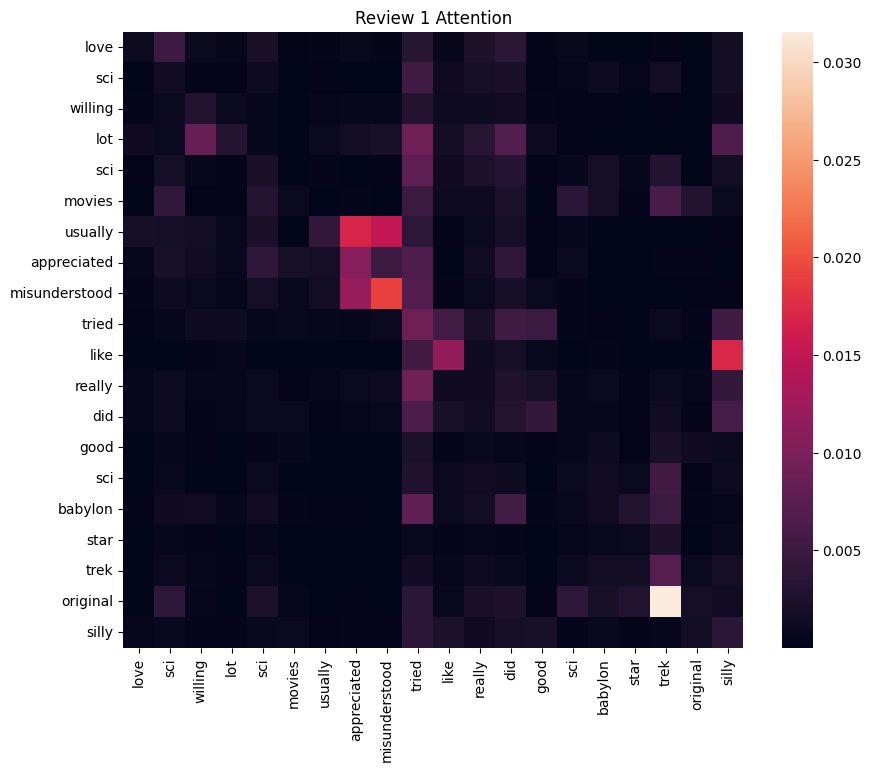


===== Review 2 =====
Worth the entertainment value of a rental, especially if you like action movies. This one features the usual car chases, fights with the great Van Damme kick style, shooting battles with the 40 shell load shotgun, and even terrorist style bombs. All of this is entertaining and competently handled but there is nothing that really blows you away if you've seen your share before.<br /><br />The plot is made interesting by the inclusion of a rabbit, which is clever but hardly profound. Many of the c...
Prediction: Negative


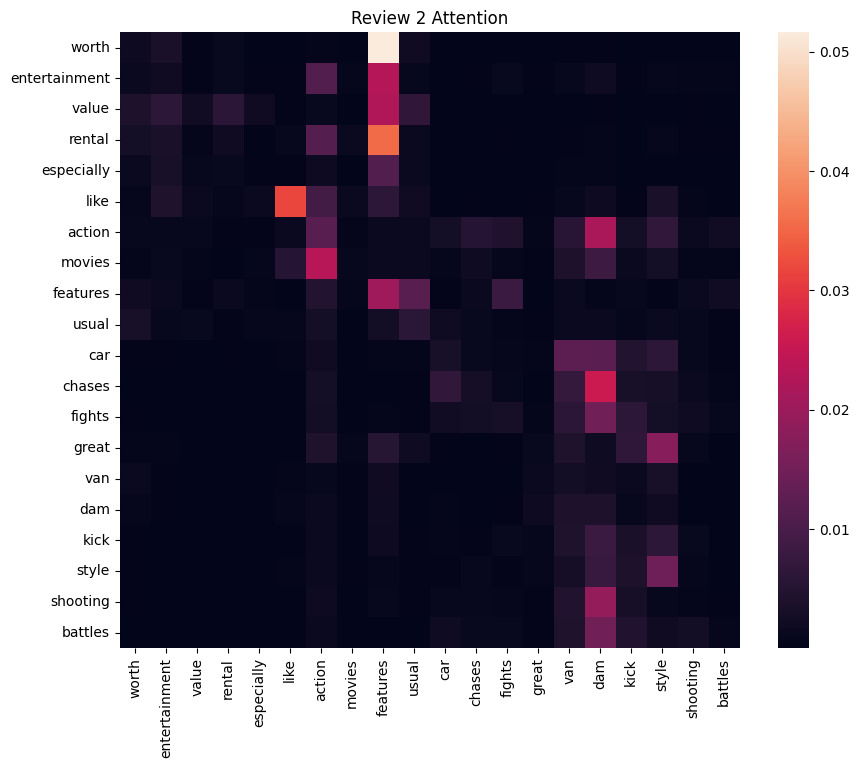


===== Review 3 =====
its a totally average film with a few semi-alright action sequences that make the plot seem a little better and remind the viewer of the classic van dam films. parts of the plot don't make sense and seem to be added in to use up time. the end plot is that of a very basic type that doesn't leave the viewer guessing and any twists are obvious from the beginning. the end scene with the flask backs don't make sense as they are added in and seem to have little relevance to the history of van dam's ch...
Prediction: Negative


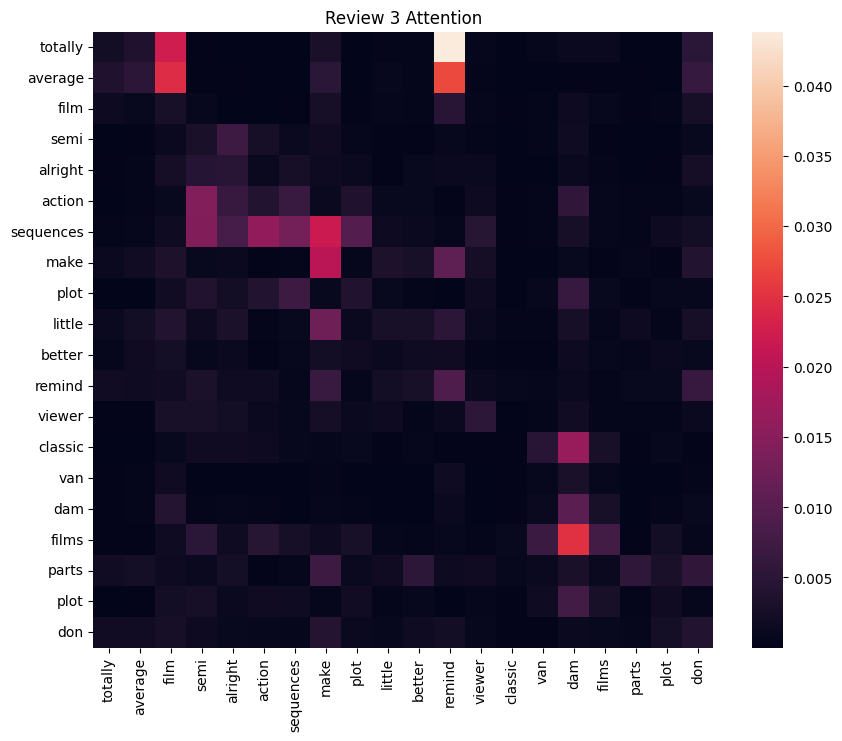


===== Review 4 =====
STAR RATING: ***** Saturday Night **** Friday Night *** Friday Morning ** Sunday Night * Monday Morning <br /><br />Former New Orleans homicide cop Jack Robideaux (Jean Claude Van Damme) is re-assigned to Columbus, a small but violent town in Mexico to help the police there with their efforts to stop a major heroin smuggling operation into their town. The culprits turn out to be ex-military, lead by former commander Benjamin Meyers (Stephen Lord, otherwise known as Jase from East Enders) who is ...
Prediction: Negative


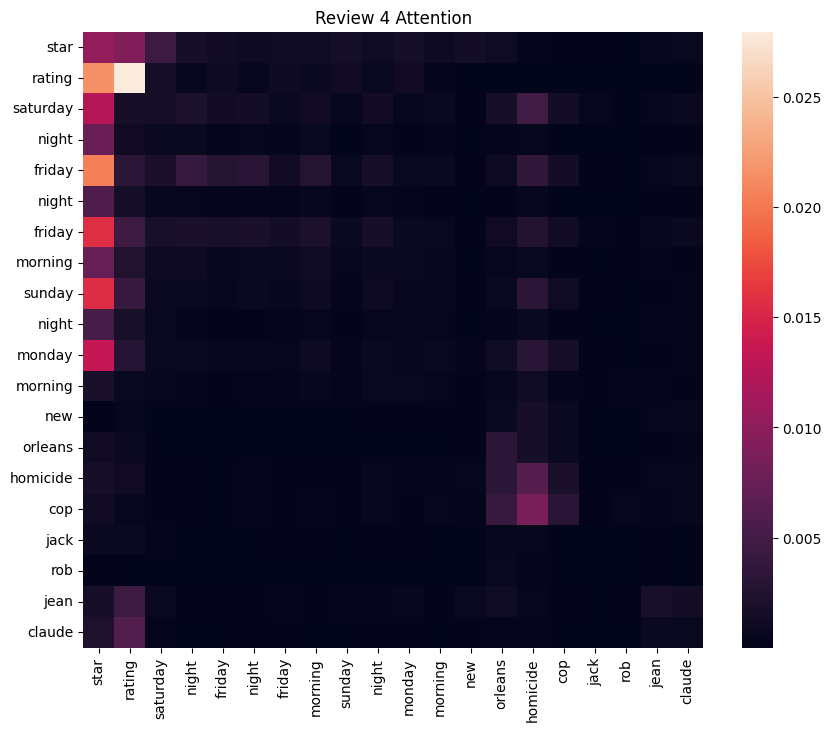


===== Review 5 =====
First off let me say, If you haven't enjoyed a Van Damme movie since bloodsport, you probably will not like this movie. Most of these movies may not have the best plots or best actors but I enjoy these kinds of movies for what they are. This movie is much better than any of the movies the other action guys (Segal and Dolph) have thought about putting out the past few years. Van Damme is good in the movie, the movie is only worth watching to Van Damme fans. It is not as good as Wake of Death (whi...
Prediction: Positive


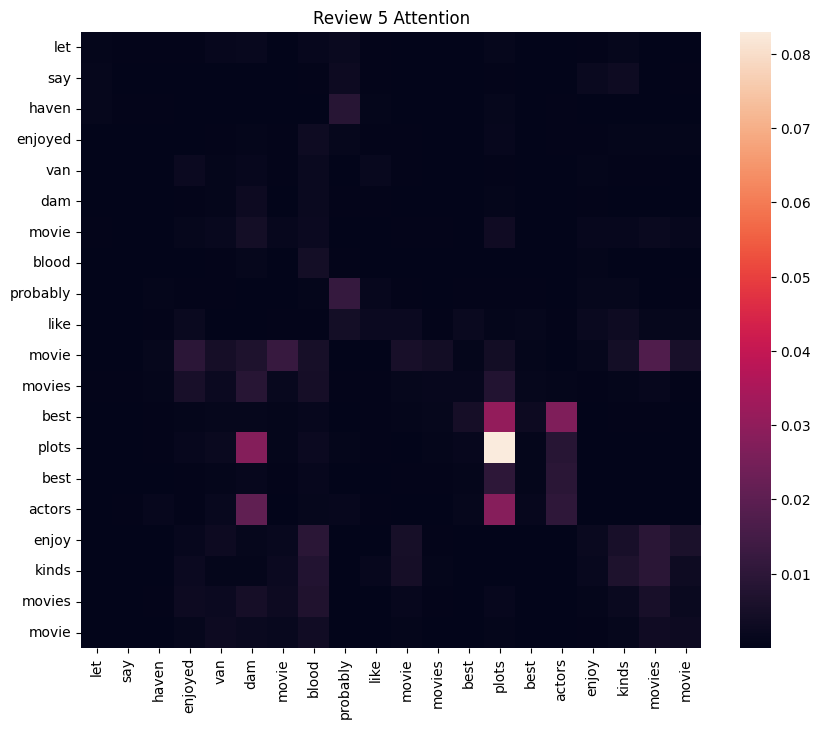

In [33]:
# Visualize attention
def show_review(text, max_chars=500):
    return text[:max_chars] + "..." if len(text) > max_chars else text

for i, res in enumerate(results):
    print(f"\n===== Review {i+1} =====")
    print(show_review(res["text"]))   # 👈 FULL REVIEW HERE
    print("Prediction:", "Positive" if res["prediction"]==1 else "Negative")

    attn = res["attentions"][-1][0][0].numpy()
    tokens = res["tokens"]

    clean_tokens, clean_attn = clean_tokens_and_attention(tokens, attn)

    plot_attention(
        clean_tokens[:20],
        clean_attn[:20, :20],
        f"Review {i+1} Attention"
    )

In [34]:
# get important words
def get_important_words(tokens, attention):
    scores = attention.mean(axis=0)

    word_scores = list(zip(tokens, scores))
    word_scores = sorted(word_scores, key=lambda x: x[1], reverse=True)

    return word_scores[:5]

In [35]:
# show important words
for i, res in enumerate(results):
    attn = res["attentions"][-1][0][0].numpy()
    tokens = res["tokens"]

    clean_tokens, clean_attn = clean_tokens_and_attention(tokens, attn)

    important = get_important_words(clean_tokens, clean_attn)

    print(f"\nReview {i+1}")
    print("Prediction:", "Positive" if res["prediction"]==1 else "Negative")
    print("Top words:", important)


Review 1
Prediction: Negative
Top words: [('dull', np.float32(0.0055559673)), ('edited', np.float32(0.0049836338)), ('watching', np.float32(0.004434351)), ('foolish', np.float32(0.004281964)), ('watch', np.float32(0.004233813))]

Review 2
Prediction: Negative
Top words: [('features', np.float32(0.006330486)), ('hamlet', np.float32(0.0061393604)), ('handled', np.float32(0.0042321295)), ('fight', np.float32(0.003351047)), ('dam', np.float32(0.0032872576))]

Review 3
Prediction: Negative
Top words: [('watching', np.float32(0.010945517)), ('little', np.float32(0.0076550646)), ('worth', np.float32(0.0073210327)), ('directed', np.float32(0.007095779)), ('disappointed', np.float32(0.0068800566))]

Review 4
Prediction: Negative
Top words: [('appeared', np.float32(0.0056205103)), ('director', np.float32(0.0048293816)), ('worst', np.float32(0.004689197)), ('dull', np.float32(0.0038105077)), ('films', np.float32(0.003451418))]

Review 5
Prediction: Positive
Top words: [('action', np.float32(0.01

In [36]:
# compare positive + negative
positive_words = []
negative_words = []

for res in results:
    attn = res["attentions"][-1][0][0].numpy()
    tokens = res["tokens"]

    clean_tokens, clean_attn = clean_tokens_and_attention(tokens, attn)

    top_words = get_important_words(clean_tokens, clean_attn)

    if res["prediction"] == 1:
        positive_words.extend([w[0] for w in top_words])
    else:
        negative_words.extend([w[0] for w in top_words])

print("\nPositive important words:", positive_words)
print("Negative important words:", negative_words)


Positive important words: ['action', 'guys', 'death', 'worth', 'hell']
Negative important words: ['dull', 'edited', 'watching', 'foolish', 'watch', 'features', 'hamlet', 'handled', 'fight', 'dam', 'watching', 'little', 'worth', 'directed', 'disappointed', 'appeared', 'director', 'worst', 'dull', 'films']
